# Training pipeline

## 0. Set-up

### Imports



In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np
#from tqdm.notebook import tqdm
from tqdm import tqdm
import seaborn as sns # Great for histograms

from performance_boosting import PBClosedLoop, PBLoss, PinballLossWrapper, CVaRLossWrapper
from ren import ContractiveREN
from robot import RobotPlant, ProportionalController, StabilizedRobot
from plot_functions import plot_pb_trajectories
from batch_generation import generate_random_batch

### Simulation parameters

In [2]:
#setup device
device = torch.device("cpu")
print(f"Using device: {device}")

#seed
seed = 0

# --- 1.Physics Parameters ---
#disturbance parameters
x0_std = 0.2
noise_std = 0.

#controller parameters
kp = 1.

#physics parameters
n_agents = 1
state_dim = 4
input_dim = 2
dt = 0.05

#nominal model parameters
b_nom = 1
m_nom = 1
b2_nom = 0.2

#simulator parameters
b_sim = 1
m_sim = 1
b2_sim = 0.2

#ren parameters
initialization_std = 0.1
dim_internal = 4
dim_nl = 4

# --- 2. Loss Parameters (Q and R) ---
# Base Q for 1 agent: Penalize pos_x, pos_y, vel_x, vel_y shape (4, 4)
alpha_x = 1
Q_agent = torch.diag(torch.tensor([1.0, 1.0, 1.0, 1.0])) * alpha_x
# Expand Q for N agents (Block Diagonal): (4 * n_agents, 4 * n_agents)
Q = torch.kron(torch.eye(n_agents), Q_agent)

# Base R for 1 agent: Penalize force_x, force_y shape (2, 2)
alpha_u = 0.0002
R_agent = torch.eye(2) * alpha_u
# Expand R for N agents: (2 * n_agents, 2 * n_agents)
R = torch.kron(torch.eye(n_agents), R_agent)

# Weight for obstacle avoidance
alpha_obs = 100.0

# --- 3. Obstacles Parameters ---
obs_centers = [torch.tensor([-0.5, -0.5])]
obs_sigmas  = [torch.tensor([0.2, 0.2])]

# --- 4. Target State: All agents to go to origin (0,0) with 0 velocity.
x_target = torch.zeros(4 * n_agents)

#------ 5. Conditional Parameters----------
conditional_training = False
#true certification goals
alpha_true = 0.05       # Probability threshold w/r draw of calibration data
delta = 0.05            # Probability threshold w/r nonconformity score violation
m_cert = 1000          # Size of certification dataset (large because pseudo-conditional)
#Calculate the shift in alpha for conditional certificates
if conditional_training:
    epsilon_cert = np.sqrt(np.log(2 / delta) / (2 * m_cert))
else:
    epsilon_cert = 0
# Shift training alpha
alpha_train = alpha_true - epsilon_cert

# #------ 6. Horizon of episodes ----------
horizon = 500

Using device: cpu


### Set seed

In [3]:
seed = 0
torch.manual_seed(seed)
np.random.seed(seed)

### Initialize fixed validation set

In [3]:
# Fixed validation sets (small for ERM tracking, large for stable CVaR model selection)
fixed_val_w = generate_random_batch(
    batch_size=50,
    horizon=horizon,
    n_agents=n_agents,
    x0_std=x0_std,
    noise_std=noise_std,
    device=device,
)

fixed_val_w_cvar = generate_random_batch(
    batch_size=2000,
    horizon=horizon,
    n_agents=n_agents,
    x0_std=x0_std,
    noise_std=noise_std,
    device=device,
)

### Prepare simulator, nominal model and stabilizing controller

In [4]:
#Open loop real plant (unknown)
sim_OL_plant = RobotPlant(b = b_sim, b2 = b2_sim, m = m_sim, n_agents = n_agents).to(device)
#Open loop nominal model
nominal_OL_plant = RobotPlant(b = b_nom, b2 = b2_nom, m = m_nom, n_agents = n_agents).to(device)
#Proportional controller
base_controller = ProportionalController(kp = kp, n_agents = n_agents).to(device)
#Stabilized real plant (closed loop of real plant and base controller) (unknown)
f_sim = StabilizedRobot(sim_OL_plant, base_controller).to(device)
#Stabilized nominal model (closed loop of nominal model and base controller) (I could use a different controller as long as this is a stable closed loop or if I use the base controller of the real plant I have to make sure it stabilizes my model as well)
f_nom = StabilizedRobot(nominal_OL_plant, base_controller).to(device)

#Freeze the physics/nominal models
for param in f_sim.parameters():
    param.requires_grad = False
for param in f_nom.parameters():
    param.requires_grad = False

## 1. Training: empirical risk loss


### Set seed

In [6]:
seed = 1
torch.manual_seed(seed)
np.random.seed(seed)

### Define trainable REN and associated closed loop

In [7]:
#Ren
ren = ContractiveREN(dim_in=state_dim*n_agents, dim_out=input_dim*n_agents, dim_internal=dim_internal, dim_nl=dim_nl, initialization_std=initialization_std).to(device)

#Closed loop of Performance boosting controller and simulator of closed loop
PB_closed_loop_sim = PBClosedLoop(ren, f_sim, f_nom).to(device)

### Training hyperparameters

In [8]:
num_training_steps = 4000
log_interval = 100
batch_size = 256
lr = 0.0003

# ERM training stability
max_grad_norm = 5.0

# Early stopping (checked every log_interval steps)
early_stop_patience = 8
early_stop_min_delta = 1e-3

### Training loop


Starting online ERM training on cpu...


ERM Training Steps: 100%|██████████| 4000/4000 [23:32<00:00,  2.83it/s, Train Mean=0.4692, Val Mean=0.4707, Best Val=0.4714, Bad Val=4/8]


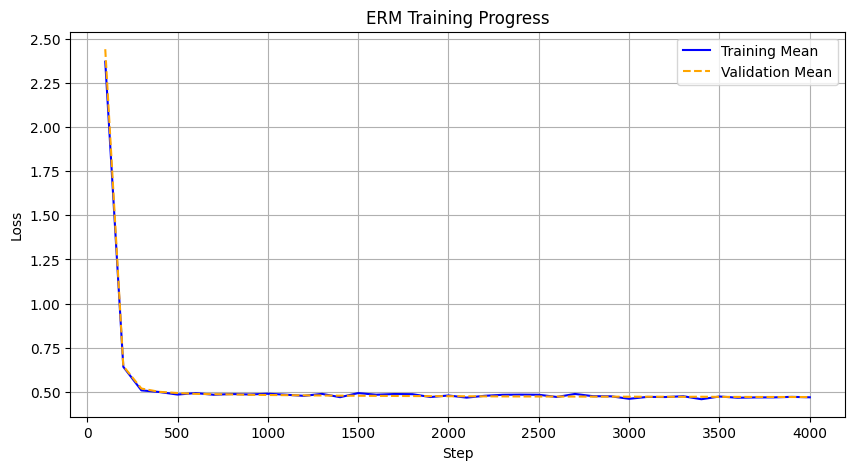

In [ ]:
# Instantiate loss and move to device
loss_fn = PBLoss(
    x_target, Q, R, lambda_obs=alpha_obs,
    obs_centers=obs_centers, obs_sigmas=obs_sigmas, n_agents=n_agents
).to(device)

optimizer = torch.optim.Adam(PB_closed_loop_sim.parameters(), lr=lr)

# Lists for plotting
train_losses = []
val_losses = []

# Best checkpoint tracking
best_val_loss = float("inf")
num_bad_val_steps = 0

# Only store latest validation batch trajectories for plotting
last_traj_x_val = None
last_traj_u_val = None
last_traj_w_hat_val = None

print(f"Starting online ERM training on {device}...")
pbar = tqdm(range(num_training_steps), desc="ERM Training Steps")

for step in pbar:
    PB_closed_loop_sim.train()
    optimizer.zero_grad()

    # 1) Generate fresh training batch
    batch_w = generate_random_batch(batch_size, horizon, n_agents, x0_std, noise_std, device)

    # 2) Run simulation and compute ERM objective (mean PB loss)
    traj_x_train, traj_u_train, traj_w_hat_train = PB_closed_loop_sim.run(batch_w)
    loss, _, _, _ = loss_fn(traj_x_train, traj_u_train)

    # 3) Backprop + clipped update
    loss.backward()
    torch.nn.utils.clip_grad_norm_(PB_closed_loop_sim.parameters(), max_grad_norm)
    optimizer.step()

    # --- Validation & logging ---
    if (step + 1) % log_interval == 0:
        PB_closed_loop_sim.eval()
        with torch.no_grad():
            # Use large fixed validation set for apples-to-apples with CVaR
            traj_x_val, traj_u_val, traj_w_hat_val = PB_closed_loop_sim.run(fixed_val_w_cvar)
            val_loss, _, _, _ = loss_fn(traj_x_val, traj_u_val)

        train_losses.append(loss.item())
        val_losses.append(val_loss.item())

        # Keep latest validation trajectories for plotting
        last_traj_x_val = traj_x_val.detach().cpu()
        last_traj_u_val = traj_u_val.detach().cpu()
        last_traj_w_hat_val = traj_w_hat_val.detach().cpu()

        # Save best checkpoint by validation mean PB loss
        improved = (best_val_loss - val_loss.item()) > early_stop_min_delta
        if improved:
            best_val_loss = val_loss.item()
            num_bad_val_steps = 0
            torch.save({
                "ren_state": ren.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "step": step,
                "val_loss": best_val_loss,
            }, "ren_standard_checkpoint.pt")
        else:
            num_bad_val_steps += 1

        pbar.set_postfix({
            "Train Mean": f"{loss.item():.4f}",
            "Val Mean": f"{val_loss.item():.4f}",
            "Best Val": f"{best_val_loss:.4f}",
            "Bad Val": f"{num_bad_val_steps}/{early_stop_patience}",
        })

        if num_bad_val_steps >= early_stop_patience:
            print(
                f"Early stopping at step {step + 1}: no Val mean improvement > {early_stop_min_delta} "
                f"for {early_stop_patience} validation checks."
            )
            break

# --- Plotting ---
plt.figure(figsize=(10, 5))
plt.plot(range(log_interval, log_interval * (len(train_losses) + 1), log_interval), train_losses, label="Training Mean", color="blue")
plt.plot(range(log_interval, log_interval * (len(val_losses) + 1), log_interval), val_losses, label="Validation Mean", color="orange", linestyle="--")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("ERM Training Progress")
plt.legend()
plt.grid(True)
plt.show()

### Plots


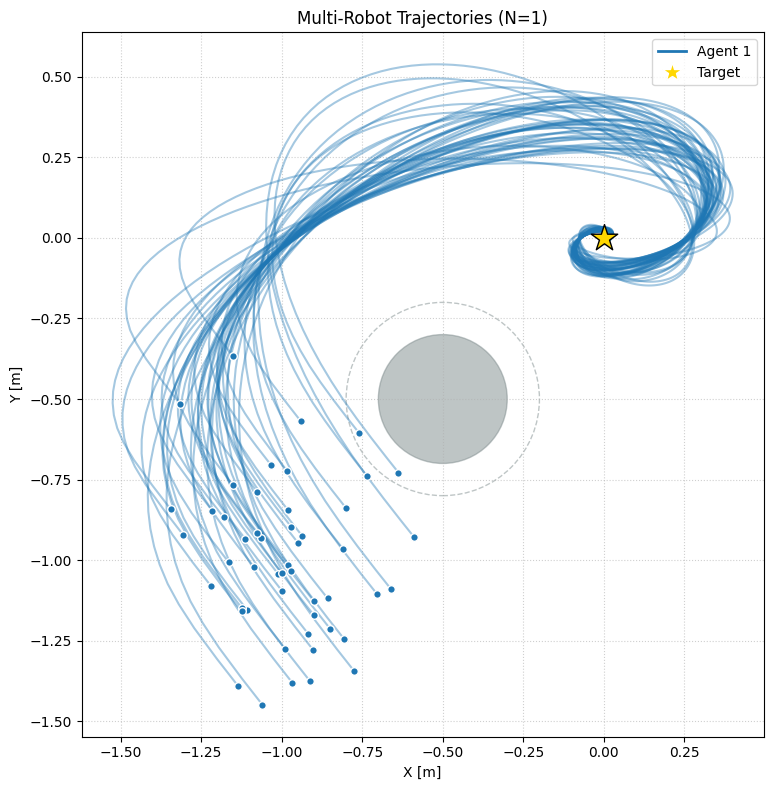

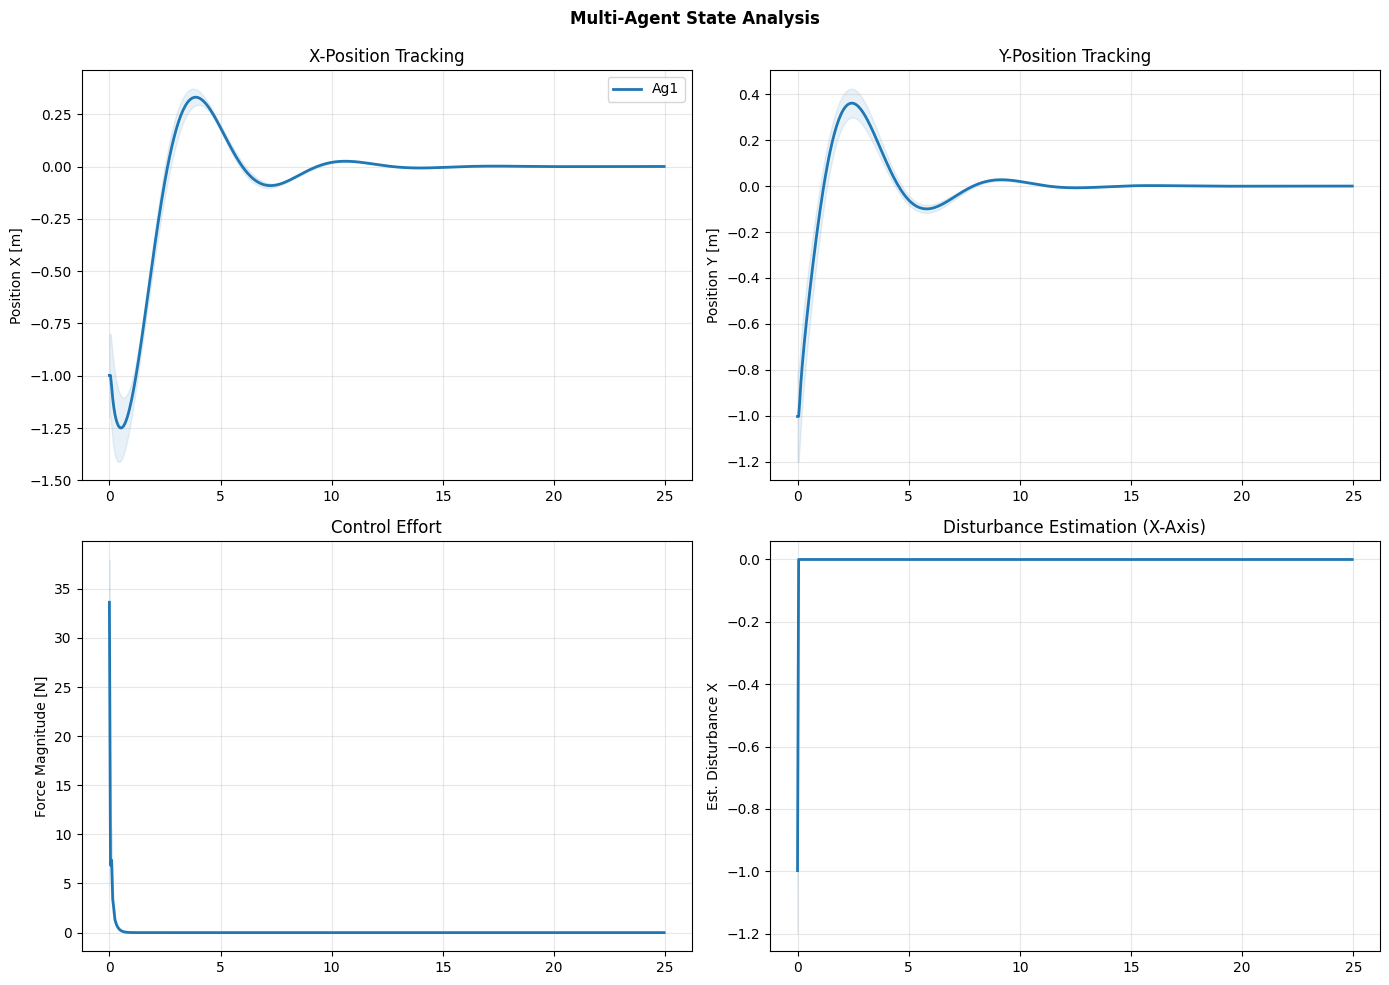

In [10]:
plot_pb_trajectories(
    traj_x=last_traj_x_val,
    traj_u=last_traj_u_val,
    traj_w_hat=traj_w_hat_val,
    x_target=x_target,
    obs_centers=obs_centers,
    obs_sigma=obs_sigmas,
    dt=dt
)

## 2. Training: CVaR Loss

### Set seed

In [11]:
seed = 2
torch.manual_seed(seed)
np.random.seed(seed)

### Define trainable REN and associated closed loop

In [12]:
#Ren
ren_quantile = ContractiveREN(dim_in=state_dim*n_agents, dim_out=input_dim*n_agents, dim_internal=dim_internal, dim_nl=dim_nl, initialization_std=initialization_std).to(device)

#Closed loop of Performance boosting controller and simulator of closed loop
PB_closed_loop_sim_quantile = PBClosedLoop(ren_quantile, f_sim, f_nom).to(device)

### Training hyperparameters

In [13]:
num_training_steps = 4000
log_interval = 100
batch_size = 256
lr = 0.0003

# CVaR training stability
max_grad_norm = 5.0
alpha_start = 0.20

# Early stopping (checked every log_interval steps)
early_stop_patience = 8
early_stop_min_delta = 1e-3

### Training loop

Warm-start loaded 9 tensors from ren_standard_checkpoint.pt | missing=2, unexpected=0, skipped=0
Initialized tau at 0.4942
Starting online CVaR training on cpu...


CVaR Training Steps: 100%|██████████| 4000/4000 [33:25<00:00,  1.99it/s, Train Obj=0.5566, Val CVaR tgt=0.5374, Val CVaR curr=0.5374, Val Mean=0.4291, Best CVaR=0.5375, Bad Val=1/8, Tau=0.4792, Alpha=0.050]    


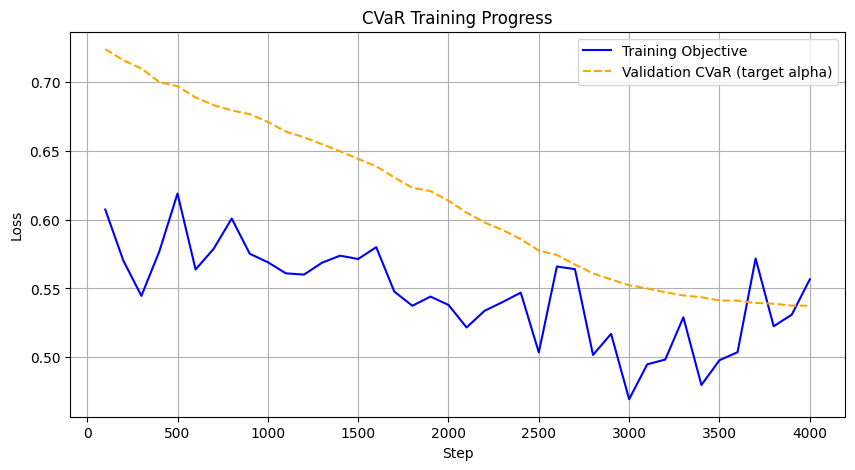

In [ ]:
# Optional warm-start from ERM checkpoint (robust to key/shape mismatches)
warm_start_path = "ren_standard_checkpoint.pt"
try:
    ckpt = torch.load(warm_start_path, map_location=device)
    ren_state = ckpt["ren_state"] if "ren_state" in ckpt else ckpt
    model_state = ren_quantile.state_dict()
    transient_keys = {"x", "init_x"}
    compatible_state = {}
    skipped_keys = []
    for key, value in ren_state.items():
        if key in transient_keys:
            continue
        if key in model_state and model_state[key].shape == value.shape:
            compatible_state[key] = value
        else:
            skipped_keys.append(key)
    if len(compatible_state) == 0:
        print(f"Warm-start skipped: no compatible keys found in {warm_start_path}.")
    else:
        load_result = ren_quantile.load_state_dict(compatible_state, strict=False)
        print(
            f"Warm-start loaded {len(compatible_state)} tensors from {warm_start_path} "
            f"| missing={len(load_result.missing_keys)}, unexpected={len(load_result.unexpected_keys)}, skipped={len(skipped_keys)}"
        )
except FileNotFoundError:
    print(f"Warm-start checkpoint not found at {warm_start_path}. Training from random init.")
except Exception as exc:
    print(f"Warm-start failed ({exc}). Training from random init.")

# Instantiate metric and move to device
metric = PBLoss(
    x_target, Q, R, lambda_obs=alpha_obs,
    obs_centers=obs_centers, obs_sigmas=obs_sigmas, n_agents=n_agents
).to(device)

# 1. Setup CVaR loss wrapper
loss_wrapper = CVaRLossWrapper(alpha=alpha_start, metric=metric).to(device)

# Fixed validation alpha for model selection / early stopping
val_alpha_target = alpha_train

# Initialize tau near an empirical upper-tail quantile for stability
with torch.no_grad():
    warmup_w = generate_random_batch(
        batch_size=max(512, batch_size),
        horizon=horizon,
        n_agents=n_agents,
        x0_std=x0_std,
        noise_std=noise_std,
        device=device,
    )
    warmup_x, warmup_u, _ = PB_closed_loop_sim_quantile.run(warmup_w)
    warmup_scores, _, _, _ = metric(warmup_x, warmup_u)
    tau_init = torch.quantile(warmup_scores, 1.0 - alpha_start)
    loss_wrapper.tau.copy_(tau_init)
print(f"Initialized tau at {loss_wrapper.tau.item():.4f}")

# Optimize controller and tau jointly
optimizer = torch.optim.Adam(
    list(PB_closed_loop_sim_quantile.parameters()) + [loss_wrapper.tau],
    lr=lr,
    )

# Lists for plotting
train_losses = []
val_losses = []

# Best checkpoint tracking by validation CVaR at target alpha
best_val_loss_quantile = float("inf")
num_bad_val_steps = 0

# Only store the very last batch's trajectories for plotting to save RAM
last_traj_x_train = None
last_traj_u_train = None
last_traj_w_hat_train = None

last_traj_x_val = None
last_traj_u_val = None
last_traj_w_hat_val = None

print(f"Starting online CVaR training on {device}...")
pbar = tqdm(range(num_training_steps), desc="CVaR Training Steps")

for step in pbar:
    PB_closed_loop_sim_quantile.train()
    optimizer.zero_grad()

    # Anneal alpha from easier tail objective to target alpha_train
    progress = step / max(1, num_training_steps - 1)
    loss_wrapper.alpha = alpha_start + (alpha_train - alpha_start) * progress

    batch_w = generate_random_batch(batch_size, horizon, n_agents, x0_std, noise_std, device)
    traj_x_train, traj_u_train, traj_w_hat_train = PB_closed_loop_sim_quantile.run(batch_w)

    loss, _, _, _ = loss_wrapper(traj_x_train, traj_u_train)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(PB_closed_loop_sim_quantile.parameters(), max_grad_norm)
    optimizer.step()

    if (step + 1) % log_interval == 0:
        PB_closed_loop_sim_quantile.eval()
        with torch.no_grad():
            traj_x_val, traj_u_val, traj_w_hat_val = PB_closed_loop_sim_quantile.run(fixed_val_w_cvar)
            val_scores, _, _, _ = metric(traj_x_val, traj_u_val)

            # Curriculum-alpha CVaR (for monitoring only)
            tail_k_curr = max(1, int(np.ceil(loss_wrapper.alpha * val_scores.numel())))
            val_cvar_curr = torch.topk(val_scores, k=tail_k_curr, largest=True).values.mean()

            # Fixed target-alpha CVaR (for checkpointing / early stopping)
            tail_k_target = max(1, int(np.ceil(val_alpha_target * val_scores.numel())))
            val_cvar_target = torch.topk(val_scores, k=tail_k_target, largest=True).values.mean()

            val_mean = val_scores.mean()

        train_losses.append(loss.item())
        val_losses.append(val_cvar_target.item())

        # Keep latest validation trajectories for plotting
        last_traj_x_val = traj_x_val.detach().cpu()
        last_traj_u_val = traj_u_val.detach().cpu()
        last_traj_w_hat_val = traj_w_hat_val.detach().cpu()

        # Save best checkpoint by target-alpha validation CVaR
        improved = (best_val_loss_quantile - val_cvar_target.item()) > early_stop_min_delta
        if improved:
            best_val_loss_quantile = val_cvar_target.item()
            num_bad_val_steps = 0
            torch.save({
                "ren_state": ren_quantile.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "tau": loss_wrapper.tau.item(),
                "alpha_current": float(loss_wrapper.alpha),
                "step": step,
                "val_cvar": best_val_loss_quantile,
                "val_cvar_target": val_cvar_target.item(),
                "val_cvar_curr": val_cvar_curr.item(),
                "val_mean": val_mean.item(),
            }, "ren_cvar_checkpoint.pt")
        else:
            num_bad_val_steps += 1

        pbar.set_postfix({
            "Train Obj": f"{loss.item():.4f}",
            "Val CVaR tgt": f"{val_cvar_target.item():.4f}",
            "Val CVaR curr": f"{val_cvar_curr.item():.4f}",
            "Val Mean": f"{val_mean.item():.4f}",
            "Best CVaR": f"{best_val_loss_quantile:.4f}",
            "Bad Val": f"{num_bad_val_steps}/{early_stop_patience}",
            "Tau": f"{loss_wrapper.tau.item():.4f}",
            "Alpha": f"{loss_wrapper.alpha:.3f}",
        })

        if num_bad_val_steps >= early_stop_patience:
            print(
                f"Early stopping at step {step + 1}: no target-alpha Val CVaR improvement > {early_stop_min_delta} "
                f"for {early_stop_patience} validation checks."
            )
            break

# --- PLOTTING ---
plt.figure(figsize=(10, 5))
plt.plot(range(log_interval, log_interval * (len(train_losses) + 1), log_interval), train_losses, label="Training Objective", color="blue")
plt.plot(range(log_interval, log_interval * (len(val_losses) + 1), log_interval), val_losses, label="Validation CVaR (target alpha)", color="orange", linestyle="--")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("CVaR Training Progress")
plt.legend()
plt.grid(True)
plt.show()

### Plots


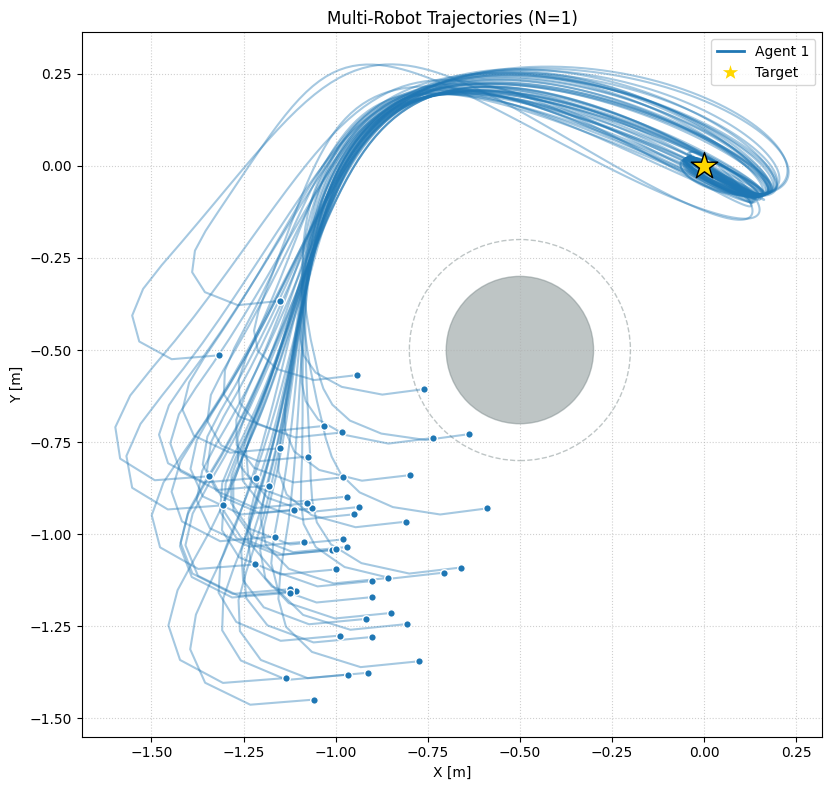

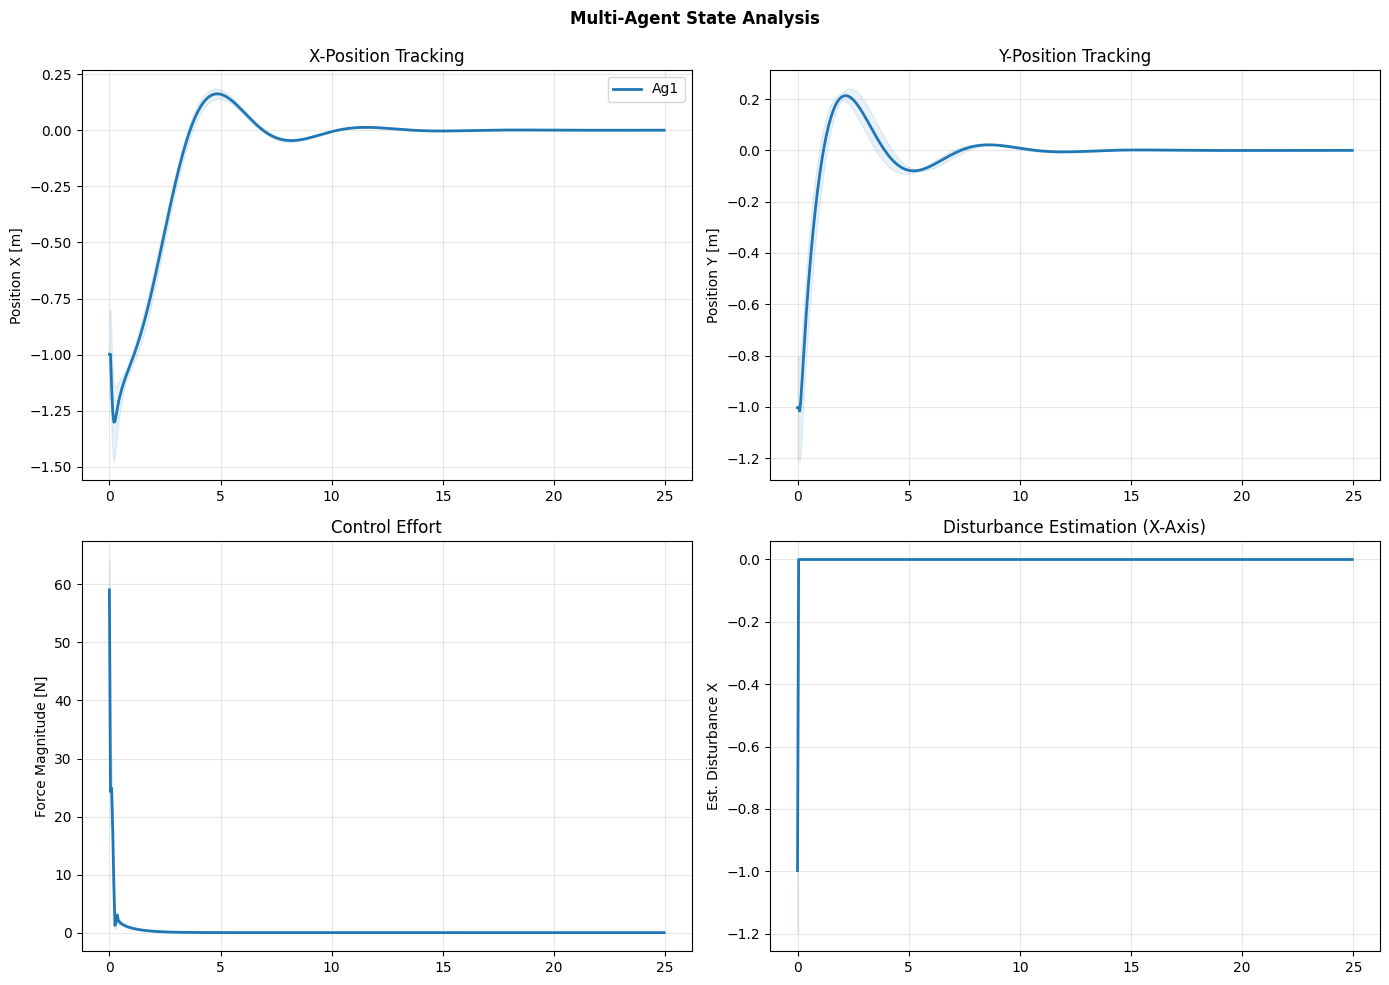

In [15]:
plot_pb_trajectories(
    traj_x=last_traj_x_val,
    traj_u=last_traj_u_val,
    traj_w_hat=last_traj_w_hat_val,
    x_target=x_target,
    obs_centers=obs_centers,
    obs_sigma=obs_sigmas,
    dt=dt
)

## Training: CVaR Loss with time-scale separation

### Set seed

In [ ]:
seed = 3
torch.manual_seed(seed)
np.random.seed(seed)

### Define trainable REN and associated closed loop

In [ ]:
#Ren
ren_quantile = ContractiveREN(dim_in=state_dim*n_agents, dim_out=input_dim*n_agents, dim_internal=dim_internal, dim_nl=dim_nl, initialization_std=initialization_std).to(device)

#Closed loop of Performance boosting controller and simulator of closed loop
PB_closed_loop_sim_quantile = PBClosedLoop(ren_quantile, f_sim, f_nom).to(device)

### Training hyperparameters

In [ ]:
num_training_steps = 4000
log_interval = 100
batch_size = 256

# Time-scale separation hyperparameters
lr_theta = 0.0003       # REN / closed-loop parameters (slow)
lr_tau = 0.003          # CVaR threshold tau (fast)
tau_inner_steps = 10    # number of tau updates per one theta update

# CVaR training stability
max_grad_norm = 5.0
alpha_start = 0.20

# Early stopping (checked every log_interval steps)
early_stop_patience = 8
early_stop_min_delta = 1e-3

### Training loop


In [ ]:
# Optional warm-start from ERM checkpoint (robust to key/shape mismatches)
warm_start_path = "ren_standard_checkpoint.pt"
try:
    ckpt = torch.load(warm_start_path, map_location=device)
    ren_state = ckpt["ren_state"] if "ren_state" in ckpt else ckpt
    model_state = ren_quantile.state_dict()
    transient_keys = {"x", "init_x"}
    compatible_state = {}
    skipped_keys = []
    for key, value in ren_state.items():
        if key in transient_keys:
            continue
        if key in model_state and model_state[key].shape == value.shape:
            compatible_state[key] = value
        else:
            skipped_keys.append(key)
    if len(compatible_state) == 0:
        print(f"Warm-start skipped: no compatible keys found in {warm_start_path}.")
    else:
        load_result = ren_quantile.load_state_dict(compatible_state, strict=False)
        print(
            f"Warm-start loaded {len(compatible_state)} tensors from {warm_start_path} "
            f"| missing={len(load_result.missing_keys)}, unexpected={len(load_result.unexpected_keys)}, skipped={len(skipped_keys)}"
        )
except FileNotFoundError:
    print(f"Warm-start checkpoint not found at {warm_start_path}. Training from random init.")
except Exception as exc:
    print(f"Warm-start failed ({exc}). Training from random init.")

# Instantiate metric and move to device
metric = PBLoss(
    x_target, Q, R, lambda_obs=alpha_obs,
    obs_centers=obs_centers, obs_sigmas=obs_sigmas, n_agents=n_agents
).to(device)

# 1. Setup CVaR wrapper
loss_wrapper = CVaRLossWrapper(alpha=alpha_start, metric=metric).to(device)

# Fixed validation alpha for model selection / early stopping
val_alpha_target = alpha_train

# Initialize tau near an empirical upper-tail quantile for stability
with torch.no_grad():
    warmup_w = generate_random_batch(
        batch_size=max(512, batch_size),
        horizon=horizon,
        n_agents=n_agents,
        x0_std=x0_std,
        noise_std=noise_std,
        device=device,
    )
    warmup_x, warmup_u, _ = PB_closed_loop_sim_quantile.run(warmup_w)
    warmup_scores, _, _, _ = metric(warmup_x, warmup_u)
    tau_init = torch.quantile(warmup_scores, 1.0 - alpha_start)
    loss_wrapper.tau.copy_(tau_init)
print(f"Initialized tau at {loss_wrapper.tau.item():.4f}")

# 2. Two-time-scale optimizers: theta (slow), tau (fast)
optimizer_theta = torch.optim.Adam(PB_closed_loop_sim_quantile.parameters(), lr=lr_theta)
optimizer_tau = torch.optim.Adam([loss_wrapper.tau], lr=lr_tau)

# Lists for plotting
train_losses = []
val_losses = []

# Best checkpoint tracking by validation CVaR at target alpha
best_val_loss_quantile = float("inf")
num_bad_val_steps = 0

# Only store the very last batch's trajectories for plotting to save RAM
last_traj_x_train = None
last_traj_u_train = None
last_traj_w_hat_train = None

last_traj_x_val = None
last_traj_u_val = None
last_traj_w_hat_val = None

print(f"Starting online CVaR training on {device}...")
pbar = tqdm(range(num_training_steps), desc="CVaR Training Steps (two-time-scale)")

for step in pbar:
    PB_closed_loop_sim_quantile.train()

    # Anneal alpha from easier tail objective to target alpha_train
    progress = step / max(1, num_training_steps - 1)
    loss_wrapper.alpha = alpha_start + (alpha_train - alpha_start) * progress

    batch_w = generate_random_batch(batch_size, horizon, n_agents, x0_std, noise_std, device)

    # --- Slow time-scale update: controller parameters (theta) ---
    optimizer_theta.zero_grad()
    traj_x_train, traj_u_train, traj_w_hat_train = PB_closed_loop_sim_quantile.run(batch_w)
    loss_theta, _, _, _ = loss_wrapper(traj_x_train, traj_u_train)
    loss_theta.backward()
    torch.nn.utils.clip_grad_norm_(PB_closed_loop_sim_quantile.parameters(), max_grad_norm)
    optimizer_theta.step()

    # --- Fast time-scale updates: tau ---
    traj_x_det = traj_x_train.detach()
    traj_u_det = traj_u_train.detach()
    for _ in range(tau_inner_steps):
        optimizer_tau.zero_grad()
        loss_tau, _, _, _ = loss_wrapper(traj_x_det, traj_u_det)
        loss_tau.backward()
        optimizer_tau.step()

    # Logging objective after both updates (same batch)
    with torch.no_grad():
        loss, _, _, _ = loss_wrapper(traj_x_det, traj_u_det)

    if (step + 1) % log_interval == 0:
        PB_closed_loop_sim_quantile.eval()
        with torch.no_grad():
            traj_x_val, traj_u_val, traj_w_hat_val = PB_closed_loop_sim_quantile.run(fixed_val_w_cvar)
            val_scores, _, _, _ = metric(traj_x_val, traj_u_val)

            # Curriculum-alpha CVaR (for monitoring only)
            tail_k_curr = max(1, int(np.ceil(loss_wrapper.alpha * val_scores.numel())))
            val_cvar_curr = torch.topk(val_scores, k=tail_k_curr, largest=True).values.mean()

            # Fixed target-alpha CVaR (for checkpointing / early stopping)
            tail_k_target = max(1, int(np.ceil(val_alpha_target * val_scores.numel())))
            val_cvar_target = torch.topk(val_scores, k=tail_k_target, largest=True).values.mean()

            val_mean = val_scores.mean()

        train_losses.append(loss.item())
        val_losses.append(val_cvar_target.item())

        # Keep latest validation trajectories for plotting
        last_traj_x_val = traj_x_val.detach().cpu()
        last_traj_u_val = traj_u_val.detach().cpu()
        last_traj_w_hat_val = traj_w_hat_val.detach().cpu()

        # Save best checkpoint by target-alpha validation CVaR
        improved = (best_val_loss_quantile - val_cvar_target.item()) > early_stop_min_delta
        if improved:
            best_val_loss_quantile = val_cvar_target.item()
            num_bad_val_steps = 0
            torch.save({
                "ren_state": ren_quantile.state_dict(),
                "optimizer_theta_state": optimizer_theta.state_dict(),
                "optimizer_tau_state": optimizer_tau.state_dict(),
                "tau": loss_wrapper.tau.item(),
                "alpha_current": float(loss_wrapper.alpha),
                "step": step,
                "val_cvar": best_val_loss_quantile,
                "val_cvar_target": val_cvar_target.item(),
                "val_cvar_curr": val_cvar_curr.item(),
                "val_mean": val_mean.item(),
            }, "ren_cvar_timescale_separation_checkpoint.pt")
        else:
            num_bad_val_steps += 1

        pbar.set_postfix({
            "Train Obj": f"{loss.item():.4f}",
            "Val CVaR tgt": f"{val_cvar_target.item():.4f}",
            "Val CVaR curr": f"{val_cvar_curr.item():.4f}",
            "Val Mean": f"{val_mean.item():.4f}",
            "Best CVaR": f"{best_val_loss_quantile:.4f}",
            "Bad Val": f"{num_bad_val_steps}/{early_stop_patience}",
            "Tau": f"{loss_wrapper.tau.item():.4f}",
            "Alpha": f"{loss_wrapper.alpha:.3f}",
        })

        if num_bad_val_steps >= early_stop_patience:
            print(
                f"Early stopping at step {step + 1}: no target-alpha Val CVaR improvement > {early_stop_min_delta} "
                f"for {early_stop_patience} validation checks."
            )
            break

# --- PLOTTING ---
plt.figure(figsize=(10, 5))
plt.plot(range(log_interval, log_interval * (len(train_losses) + 1), log_interval), train_losses, label="Training Objective", color="blue")
plt.plot(range(log_interval, log_interval * (len(val_losses) + 1), log_interval), val_losses, label="Validation CVaR (target alpha)", color="orange", linestyle="--")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("CVaR Training Progress (two-time-scale)")
plt.legend()
plt.grid(True)
plt.show()

### Plots


In [ ]:
plot_pb_trajectories(
    traj_x=last_traj_x_val,
    traj_u=last_traj_u_val,
    traj_w_hat=last_traj_w_hat_val,
    x_target=x_target,
    obs_centers=obs_centers,
    obs_sigma=obs_sigmas,
    dt=dt
)

## Training: pinball loss

### Set seed

In [ ]:
seed = 4
torch.manual_seed(seed)
np.random.seed(seed)

### Define trainable REN and associated closed loop

In [ ]:
#Ren
ren_quantile = ContractiveREN(dim_in=state_dim*n_agents, dim_out=input_dim*n_agents, dim_internal=dim_internal, dim_nl=dim_nl, initialization_std=initialization_std).to(device)

#Closed loop of Performance boosting controller and simulator of closed loop
PB_closed_loop_sim_quantile = PBClosedLoop(ren_quantile, f_sim, f_nom).to(device)

### Training hyperparameters

In [ ]:
num_training_steps = 1000
log_interval = 50
batch_size = 50
lr = 0.001

### Training loop

In [ ]:
#Instantiate metric and Move to Device
metric = PBLoss(x_target, Q, R, lambda_obs=alpha_obs,
                 obs_centers=obs_centers, obs_sigmas=obs_sigmas, n_agents=n_agents)

metric.to(device)  #Moves Q, R, target, and obstacles to GPU

# 1. Setup Loss Wrapper
cvar_wrapper = False
pinball_wrapper = not cvar_wrapper
if cvar_wrapper:
    loss_wrapper = CVaRLossWrapper(alpha=alpha_train, metric=metric)
elif pinball_wrapper:
    loss_wrapper = PinballLossWrapper(alpha=alpha_train, metric=metric)
loss_wrapper.to(device) # Moves tau to GPU

# We must optimize controller and tau (threshold) simultaneously
optimizer = torch.optim.Adam(
    list(PB_closed_loop_sim_quantile.parameters()) + [loss_wrapper.tau],
    lr=lr
)

# Lists for plotting
train_losses = []
val_losses = []

# Best checkpoint tracking
best_val_loss_quantile = float('inf')

# Only store the very last batch's trajectories for plotting to save RAM
last_traj_x_train = None
last_traj_u_train = None
last_traj_w_hat_train = None

last_traj_x_val = None
last_traj_u_val = None
last_traj_w_hat_val = None

print(f"Starting online training on {device}...")

# Use tqdm for a nice progress bar
pbar = tqdm(range(num_training_steps), desc="CVaR Training Steps")

for step in pbar:
    PB_closed_loop_sim_quantile.train()
    optimizer.zero_grad()

    batch_w = generate_random_batch(batch_size, horizon, n_agents, x0_std, noise_std, device)

    traj_x_train, traj_u_train, traj_w_hat_train = PB_closed_loop_sim_quantile.run(batch_w)
    # Wrapper returns optimized loss and logging stats
    loss, _, _, _ = loss_wrapper(traj_x_train, traj_u_train)

    loss.backward()
    optimizer.step()

    if (step + 1) % log_interval == 0:
        PB_closed_loop_sim_quantile.eval()

        with torch.no_grad():
            traj_x_val, traj_u_val, traj_w_hat_val = PB_closed_loop_sim_quantile.run(fixed_val_w)
            val_loss, _, _, _ = loss_wrapper(traj_x_val, traj_u_val)

        train_losses.append(loss.item())
        val_losses.append(val_loss.item())

        # Save best checkpoint
        if val_loss.item() < best_val_loss_quantile:
            best_val_loss_quantile = val_loss.item()
            torch.save({
                "ren_state": ren_quantile.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "tau": loss_wrapper.tau.item(),
                "step": step,
                "val_loss": best_val_loss_quantile,
            }, "ren_pinball_checkpoint.pt")

        pbar.set_postfix({
            'Loss Train': f"{loss.item():.4f}",
            'Loss Val': f"{val_loss.item():.4f}",
            'Best Val': f"{best_val_loss_quantile:.4f}",
            'Tau': f"{loss_wrapper.tau.item():.4f}"
        })

    if step == num_training_steps - 1:
        last_traj_x_val = traj_x_val.detach().cpu()
        last_traj_u_val = traj_u_val.detach().cpu()
        last_traj_w_hat_val = traj_w_hat_val.detach().cpu()

# --- PLOTTING ---
plt.figure(figsize=(10, 5))
plt.plot(range(log_interval, num_training_steps + 1, log_interval), train_losses, label='Training Loss', color='blue')
plt.plot(range(log_interval, num_training_steps + 1, log_interval), val_losses, label='Validation Loss', color='orange', linestyle='--')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('Performance Boosting Training Progress')
plt.legend()
plt.grid(True)
plt.show()

### Plots


In [ ]:
plot_pb_trajectories(
    traj_x=last_traj_x_val,
    traj_u=last_traj_u_val,
    traj_w_hat=last_traj_w_hat_val,
    x_target=x_target,
    obs_centers=obs_centers,
    obs_sigma=obs_sigmas,
    dt=dt
)

## Hyperparameter sweep (empirical risk)

Run this cell to compare a small grid of `(lr, batch_size)` for the empirical-risk objective and pick the best validation setting.

In [ ]:
# # Compact sweep for empirical-risk training
# # Compares several (lr, batch_size) pairs and reports the best by validation loss.

# import itertools

# # Small search grid (edit as needed)
# lr_grid = [1e-3, 5e-4, 3e-4]
# batch_grid = [50, 100]

# # Keep this shorter than full training for fast model selection
# sweep_steps = 800
# sweep_log_interval = 50

# # Keep the same validation distribution across trials
# val_batch_size = 100
# fixed_val_w_sweep = generate_random_batch(
#     batch_size=val_batch_size,
#     horizon=horizon,
#     n_agents=n_agents,
#     x0_std=x0_std,
#     noise_std=noise_std,
#     device=device,
# )

# results = []

# for trial_idx, (trial_lr, trial_batch_size) in enumerate(itertools.product(lr_grid, batch_grid), start=1):
#     # Reproducible but distinct init/data stream per trial
#     trial_seed = seed + trial_idx
#     torch.manual_seed(trial_seed)
#     np.random.seed(trial_seed)

#     # Fresh model for each hyperparameter setting
#     ren_trial = ContractiveREN(
#         dim_in=state_dim * n_agents,
#         dim_out=input_dim * n_agents,
#         dim_internal=dim_internal,
#         dim_nl=dim_nl,
#         initialization_std=initialization_std,
#     ).to(device)

#     pb_trial = PBClosedLoop(ren_trial, f_sim, f_nom).to(device)
#     optimizer_trial = torch.optim.Adam(pb_trial.parameters(), lr=trial_lr)

#     best_val = float("inf")
#     final_train = None
#     final_val = None

#     for step in range(sweep_steps):
#         pb_trial.train()
#         optimizer_trial.zero_grad()

#         batch_w = generate_random_batch(
#             batch_size=trial_batch_size,
#             horizon=horizon,
#             n_agents=n_agents,
#             x0_std=x0_std,
#             noise_std=noise_std,
#             device=device,
#         )

#         traj_x_train, traj_u_train, _ = pb_trial.run(batch_w)
#         train_loss, _, _, _ = loss_fn(traj_x_train, traj_u_train)
#         train_loss.backward()
#         optimizer_trial.step()

#         if (step + 1) % sweep_log_interval == 0:
#             pb_trial.eval()
#             with torch.no_grad():
#                 traj_x_val, traj_u_val, _ = pb_trial.run(fixed_val_w_sweep)
#                 val_loss, _, _, _ = loss_fn(traj_x_val, traj_u_val)

#             final_train = float(train_loss.item())
#             final_val = float(val_loss.item())
#             best_val = min(best_val, final_val)

#     results.append({
#         "lr": trial_lr,
#         "batch_size": trial_batch_size,
#         "best_val_loss": best_val,
#         "final_train_loss": final_train,
#         "final_val_loss": final_val,
#     })

# # Sort by best validation loss (lower is better)
# results_sorted = sorted(results, key=lambda item: item["best_val_loss"])

# print("Sweep results (sorted by best_val_loss):")
# for row in results_sorted:
#     print(
#         f"lr={row['lr']:.1e}, batch={row['batch_size']:>3d} | "
#         f"best_val={row['best_val_loss']:.4f}, "
#         f"final_train={row['final_train_loss']:.4f}, "
#         f"final_val={row['final_val_loss']:.4f}"
#     )

# best_cfg = results_sorted[0]
# print("\nBest config:", best_cfg)

# # Optional quick visualization
# labels = [f"lr={r['lr']:.1e}, b={r['batch_size']}" for r in results_sorted]
# values = [r["best_val_loss"] for r in results_sorted]

# plt.figure(figsize=(8, 4))
# plt.bar(labels, values)
# plt.ylabel("Best Validation Loss")
# plt.title("Empirical-risk Hyperparameter Sweep")
# plt.xticks(rotation=25, ha="right")
# plt.grid(axis="y", alpha=0.3)
# plt.tight_layout()
# plt.show()